In [1]:
import sys
sys.path.append('WTM')

import pickle as p
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

import new_ds
from new_ds import mm_Dataset
from WTM_model import WTM
from utils import calc_topic_uniqueness
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
pd.set_option('display.max_rows', None)
import pickle

import seaborn as sns
import networkx as nx
import time

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
def my_softmax(df):
    
    maxes = df.max(axis=1)
    diffs = df.sub(maxes, axis=0)
    num = np.exp(diffs)
    denom = num.sum(axis=1)
    out = num.div(denom, axis=0)
    return out

def load_model(model_prefix, docSet):
    checkpoint = torch.load(f'WTM_checkpoints/{model_prefix}')
    param = checkpoint["param"]
    model = WTM(**param)
    model.load_model(checkpoint["net"])
    model.id2token = {v: k for k,v in docSet.dictionary.token2id.items()}
    return model

def get_embeds(model, docSet, labels_fname = None):
    embeds = model.get_embed(train_data=docSet, num=1000)

    if labels_fname:
        with open(labels_fname, 'r') as file:
            labels_list = [line.strip() for line in file.readlines()]
        out_df = pd.DataFrame(embeds, index=labels_list)
        return out_df
        
    return pd.DataFrame(embeds)

def calculate_phis(docSet, model):
    out_dict = {}
    all_phi_raw = model.get_topic_word_dist(normalize=False)
    headers = np.concatenate([expmat.columns for expmat in docSet.expmats.values()])
    all_phi_raw = pd.DataFrame(all_phi_raw, columns = headers)
    for data_type in np.unique(docSet.label_type):
        type_raw = all_phi_raw.iloc[:, docSet.label_type==data_type]
        out_dict[data_type] = my_softmax(type_raw)
    return out_dict

In [4]:
ckpts_covid_t10_a5e2 = [f'covid_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]
ckpts_crc = [f'crc_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]
ckpts_ibd = [f'ibd_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]
ckpts_ibs = [f'ibs_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]

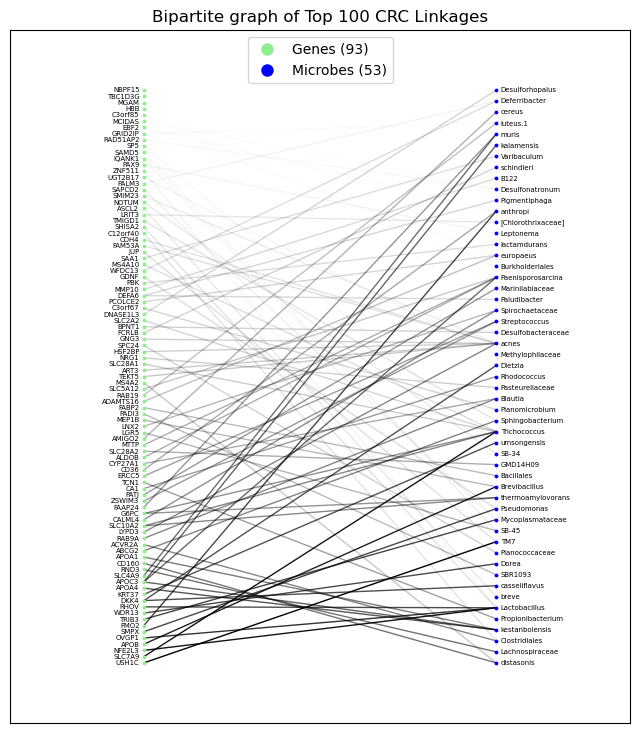

In [5]:
with open ('crc_data/crc_docDataset.pkl', 'rb') as handle:
    curr_docSet = p.load(handle)
#curr_model = load_model(ckpts_crc[-1], curr_docSet)

links_idvl = pd.read_pickle(f'crc_data/raw_linkages_persamp.p')
links_all = pd.read_pickle(f'crc_data/raw_linkages_overall.p')
stacked_links_top = links_all.stack().nlargest(100)

top_links = []
top_weights = []
for i, val in stacked_links_top.items():
    top_links.append((i[0], i[1]))
    top_weights.append(val)

max_weight = max(top_weights)
min_weight = min(top_weights)
normed_weights = [(weight - min_weight)/(max_weight - min_weight) for weight in top_weights]

plt.figure(figsize=(8, 9))
B = nx.Graph()

gene_set = np.unique([val[0] for val in top_links])
microbe_set = np.unique([val[1] for val in top_links])

B.add_nodes_from(gene_set)
B.add_nodes_from(microbe_set)
B.add_edges_from(top_links)

pos = nx.bipartite_layout(B, gene_set, scale=5)
nx.draw_networkx_nodes(B, pos, nodelist = gene_set, node_color='lightgreen', node_size=3)
nx.draw_networkx_nodes(B, pos, nodelist = microbe_set, node_color='blue', node_size=3)
nx.draw_networkx_edges(B, pos, width=top_weights, alpha=normed_weights, edge_color='black')

gene_labels = {node: curr_docSet.dictionary[node] for node in gene_set}
genelab_pos = {node: (pos[0]-1e-1, pos[1]) for node, pos in pos.items()}
nx.draw_networkx_labels(B, genelab_pos, labels=gene_labels, font_size=5, horizontalalignment='right')

microbe_labels = {node: curr_docSet.dictionary[node] for node in microbe_set}
microbelab_pos = {node: (pos[0]+1e-1, pos[1]) for node, pos in pos.items()}
nx.draw_networkx_labels(B, microbelab_pos, labels=microbe_labels, font_size=5, horizontalalignment='left')

plt.margins(x=0.3)

custom_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=10, label=f'Genes ({len(gene_set)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label=f'Microbes ({len(microbe_set)})')
]

plt.legend(handles=custom_legend, loc='upper center')

plt.title(f'Bipartite graph of Top 100 CRC Linkages')
#plt.savefig('crc_data/linkage_bipartite.png')
plt.savefig('crc_data/linkage_bipartite.svg')
plt.show()

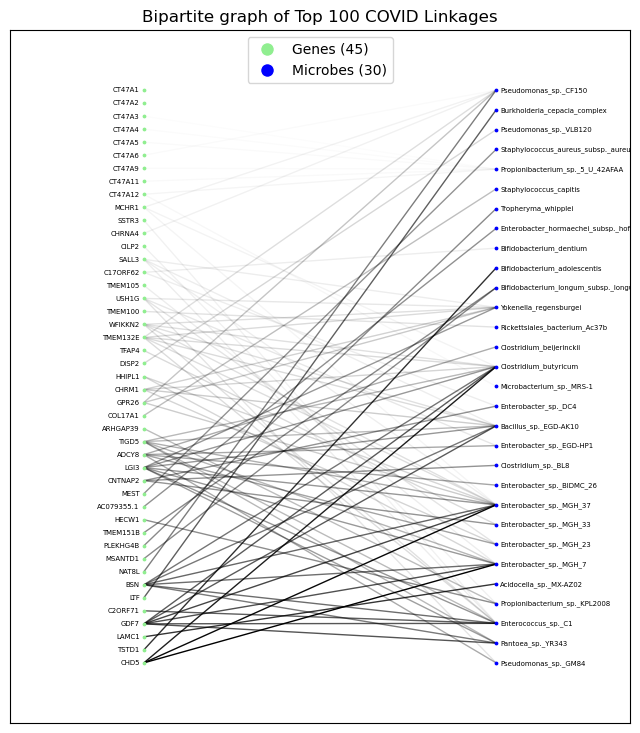

In [15]:
with open ('covid_data/covid_docDataset.pkl', 'rb') as handle:
    curr_docSet = p.load(handle)
#curr_model = load_model(ckpts_crc[-1], curr_docSet)

links_idvl = pd.read_pickle(f'covid_data/raw_linkages_persamp.p')
links_all = pd.read_pickle(f'covid_data/raw_linkages_overall.p')
stacked_links_top = links_all.stack().nlargest(100)

top_links = []
top_weights = []
for i, val in stacked_links_top.items():
    top_links.append((i[0], i[1]))
    top_weights.append(val)

max_weight = max(top_weights)
min_weight = min(top_weights)
normed_weights = [(weight - min_weight)/(max_weight - min_weight) for weight in top_weights]

plt.figure(figsize=(8, 9))
B = nx.Graph()

gene_set = np.unique([val[0] for val in top_links])
microbe_set = np.unique([val[1] for val in top_links])

B.add_nodes_from(gene_set)
B.add_nodes_from(microbe_set)
B.add_edges_from(top_links)

pos = nx.bipartite_layout(B, gene_set, scale=5)
nx.draw_networkx_nodes(B, pos, nodelist = gene_set, node_color='lightgreen', node_size=3)
nx.draw_networkx_nodes(B, pos, nodelist = microbe_set, node_color='blue', node_size=3)
nx.draw_networkx_edges(B, pos, width=top_weights, alpha=normed_weights, edge_color='black')

gene_labels = {node: curr_docSet.dictionary[node] for node in gene_set}
genelab_pos = {node: (pos[0]-1e-1, pos[1]) for node, pos in pos.items()}
nx.draw_networkx_labels(B, genelab_pos, labels=gene_labels, font_size=5, horizontalalignment='right')

microbe_labels = {node: curr_docSet.dictionary[node] for node in microbe_set}
microbelab_pos = {node: (pos[0]+1e-1, pos[1]) for node, pos in pos.items()}
nx.draw_networkx_labels(B, microbelab_pos, labels=microbe_labels, font_size=5, horizontalalignment='left')

plt.margins(x=0.3)

custom_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=10, label=f'Genes ({len(gene_set)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label=f'Microbes ({len(microbe_set)})')
]

plt.legend(handles=custom_legend, loc='upper center')

plt.title(f'Bipartite graph of Top 100 COVID Linkages')
#plt.savefig('crc_data/linkage_bipartite.png')
plt.savefig('covid_data/linkage_bipartite.svg')
plt.show()

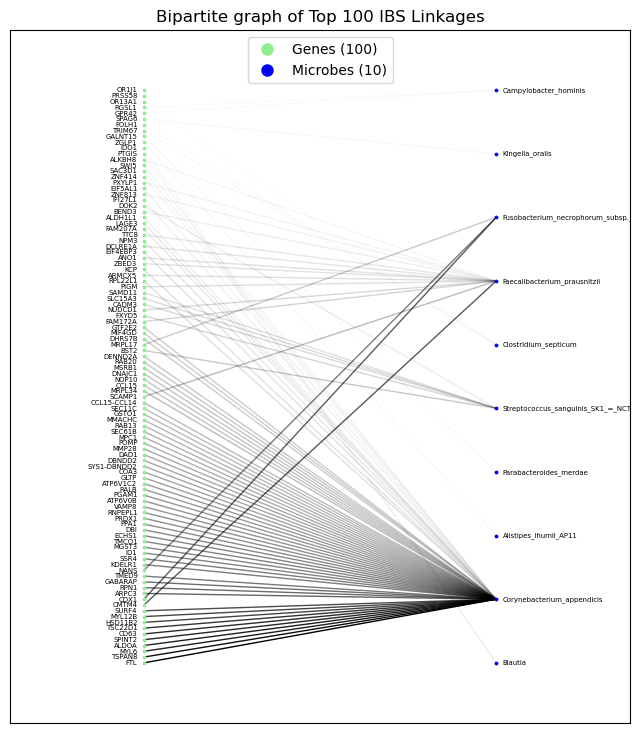

In [6]:
with open ('ibs_data/ibs_docDataset.pkl', 'rb') as handle:
    curr_docSet = p.load(handle)
#curr_model = load_model(ckpts_crc[-1], curr_docSet)

links_idvl = pd.read_pickle(f'ibs_data/raw_linkages_persamp.p')
links_all = pd.read_pickle(f'ibs_data/raw_linkages_overall.p')
stacked_links_top = links_all.stack().nlargest(100)

top_links = []
top_weights = []
for i, val in stacked_links_top.items():
    top_links.append((i[0], i[1]))
    top_weights.append(val)

max_weight = max(top_weights)
min_weight = min(top_weights)
normed_weights = [(weight - min_weight)/(max_weight - min_weight) for weight in top_weights]

plt.figure(figsize=(8, 9))
B = nx.Graph()

gene_set = np.unique([val[0] for val in top_links])
microbe_set = np.unique([val[1] for val in top_links])

B.add_nodes_from(gene_set)
B.add_nodes_from(microbe_set)
B.add_edges_from(top_links)

pos = nx.bipartite_layout(B, gene_set, scale=5)
nx.draw_networkx_nodes(B, pos, nodelist = gene_set, node_color='lightgreen', node_size=3)
nx.draw_networkx_nodes(B, pos, nodelist = microbe_set, node_color='blue', node_size=3)
nx.draw_networkx_edges(B, pos, width=top_weights, alpha=normed_weights, edge_color='black')

gene_labels = {node: curr_docSet.dictionary[node] for node in gene_set}
genelab_pos = {node: (pos[0]-1e-1, pos[1]) for node, pos in pos.items()}
nx.draw_networkx_labels(B, genelab_pos, labels=gene_labels, font_size=5, horizontalalignment='right')

microbe_labels = {node: curr_docSet.dictionary[node] for node in microbe_set}
microbelab_pos = {node: (pos[0]+1e-1, pos[1]) for node, pos in pos.items()}
nx.draw_networkx_labels(B, microbelab_pos, labels=microbe_labels, font_size=5, horizontalalignment='left')

plt.margins(x=0.3)

custom_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=10, label=f'Genes ({len(gene_set)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label=f'Microbes ({len(microbe_set)})')
]

plt.legend(handles=custom_legend, loc='upper center')

plt.title(f'Bipartite graph of Top 100 IBS Linkages')
#plt.savefig('crc_data/linkage_bipartite.png')
plt.savefig('ibs_data/linkage_bipartite.svg')
plt.show()

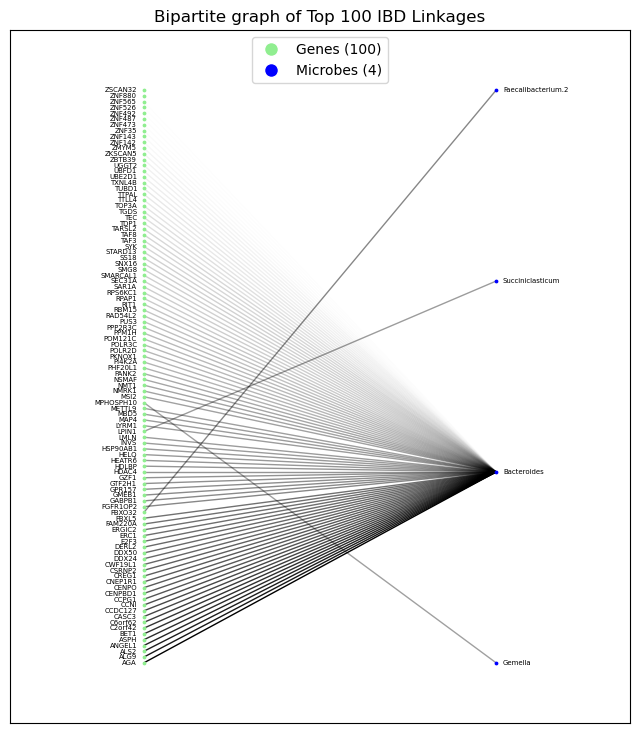

In [7]:
with open ('ibd_data/ibd_docDataset.pkl', 'rb') as handle:
    curr_docSet = p.load(handle)
#curr_model = load_model(ckpts_crc[-1], curr_docSet)

links_idvl = pd.read_pickle(f'ibd_data/raw_linkages_persamp.p')
links_all = pd.read_pickle(f'ibd_data/raw_linkages_overall.p')
stacked_links_top = links_all.stack().nlargest(100)

top_links = []
top_weights = []
for i, val in stacked_links_top.items():
    top_links.append((i[0], i[1]))
    top_weights.append(val)

max_weight = max(top_weights)
min_weight = min(top_weights)
normed_weights = [(weight - min_weight)/(max_weight - min_weight) for weight in top_weights]

plt.figure(figsize=(8, 9))
B = nx.Graph()

gene_set = np.unique([val[0] for val in top_links])
microbe_set = np.unique([val[1] for val in top_links])

B.add_nodes_from(gene_set)
B.add_nodes_from(microbe_set)
B.add_edges_from(top_links)

pos = nx.bipartite_layout(B, gene_set, scale=5)
nx.draw_networkx_nodes(B, pos, nodelist = gene_set, node_color='lightgreen', node_size=3)
nx.draw_networkx_nodes(B, pos, nodelist = microbe_set, node_color='blue', node_size=3)
nx.draw_networkx_edges(B, pos, width=top_weights, alpha=normed_weights, edge_color='black')

gene_labels = {node: curr_docSet.dictionary[node] for node in gene_set}
genelab_pos = {node: (pos[0]-1e-1, pos[1]) for node, pos in pos.items()}
nx.draw_networkx_labels(B, genelab_pos, labels=gene_labels, font_size=5, horizontalalignment='right')

microbe_labels = {node: curr_docSet.dictionary[node] for node in microbe_set}
microbelab_pos = {node: (pos[0]+1e-1, pos[1]) for node, pos in pos.items()}
nx.draw_networkx_labels(B, microbelab_pos, labels=microbe_labels, font_size=5, horizontalalignment='left')

plt.margins(x=0.3)

custom_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', markersize=10, label=f'Genes ({len(gene_set)})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label=f'Microbes ({len(microbe_set)})')
]

plt.legend(handles=custom_legend, loc='upper center')

plt.title(f'Bipartite graph of Top 100 IBD Linkages')
#plt.savefig('crc_data/linkage_bipartite.png')
plt.savefig('ibd_data/linkage_bipartite.svg')
plt.show()